# step1:   Load and view datasets

In [100]:
import pandas as pd
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [101]:
test.head()

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user
0,7001,11,71.085651,31,14,3613.133197,20,12.307634,0
1,1319,9,47.558578,23,13,6189.807969,24,5.585591,1
2,8901,10,79.631917,19,16,7425.979316,16,15.729078,1
3,9175,11,54.990557,21,14,5058.609732,26,9.082133,1
4,350,1,54.626764,3,9,5477.624691,15,11.273880,0


In [102]:
test.shape

(2532, 9)

In [103]:
train.head()

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
0,1045,16,46.079173,9,13,5462.010418,18,14.307116,1,0
1,1339,1,42.625268,24,8,4679.746955,14,26.690708,1,1
2,5144,16,67.310472,21,12,6532.157783,21,13.092315,1,1
3,7099,16,78.904027,34,14,7155.049697,28,10.564979,0,0
4,7907,8,50.456513,19,12,6214.569079,25,6.813272,1,0


In [104]:
train.shape

(7595, 10)

In [105]:
train.dtypes

id                            int64
sessions_count                int64
avg_session_time            float64
days_since_last_activity      int64
purchases_count               int64
avg_purchase_value          float64
active_days                   int64
session_std                 float64
is_weekend_user               int64
retention                     int64
dtype: object

## Dataset Features

| Variable | Type | Description |
|----------|------|-------------|
| `id` | `int` | User identifier |
| `sessions_count` | `int` | Number of sessions during the observation period |
| `avg_session_time` | `float` | Average session duration (minutes) |
| `days_since_last_activity` | `int` | Number of days since the user's last visit |
| `purchases_count` | `int` | Total number of purchases made |
| `avg_purchase_value` | `float` | Average purchase value |
| `active_days` | `int` | Number of days the user was active |
| `session_std` | `float` | Standard deviation of session duration (session variability) |
| `is_weekend_user` | `int` | Indicates whether the user is more active on weekends (`0` = No, `1` = Yes) |
| `retention` | `int` | **Target variable** (`0` = User did not return, `1` = User returned) |

In [106]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7595 entries, 0 to 7594
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        7595 non-null   int64  
 1   sessions_count            7595 non-null   int64  
 2   avg_session_time          7595 non-null   float64
 3   days_since_last_activity  7595 non-null   int64  
 4   purchases_count           7595 non-null   int64  
 5   avg_purchase_value        7595 non-null   float64
 6   active_days               7595 non-null   int64  
 7   session_std               7595 non-null   float64
 8   is_weekend_user           7595 non-null   int64  
 9   retention                 7595 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 593.5 KB


In [107]:
train.describe()

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention
count,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000,7595.000000
mean,5042.751547,10.426333,56.822155,19.565240,12.149704,5870.966510,20.233180,11.914057,0.499408,0.732192
std,2937.706237,5.643471,12.014306,9.334608,2.442620,1429.775977,4.144513,3.758870,0.500033,0.442846
min,1.000000,1.000000,23.731409,0.000000,3.000000,2097.949638,8.000000,0.000000,0.000000,0.000000
25%,2461.500000,7.000000,47.158410,13.000000,11.000000,4780.689415,17.000000,9.497875,0.000000,0.000000
50%,5042.000000,12.000000,54.467435,20.000000,12.000000,5542.283468,20.000000,11.788557,0.000000,1.000000
75%,7580.500000,15.000000,66.069138,26.000000,14.000000,6880.581191,22.000000,14.210551,1.000000,1.000000
max,10127.000000,31.000000,90.000000,55.000000,21.000000,10000.000000,30.000000,30.661213,1.000000,1.000000


# step 2:   Exploratory Data Analysis

In [108]:
train.isnull().sum()

id                          0
sessions_count              0
avg_session_time            0
days_since_last_activity    0
purchases_count             0
avg_purchase_value          0
active_days                 0
session_std                 0
is_weekend_user             0
retention                   0
dtype: int64

In [109]:
train.duplicated().sum()

np.int64(0)

In [110]:
# check the class balance of the treget dataset
train['retention'].value_counts(normalize=True)

retention
1    0.732192
0    0.267808
Name: proportion, dtype: float64

### Target Variable Distribution

| Retention |  Count (%) | Interpretation                         |
| --------- | ---------: | -------------------------------------- |
| `1`       | **73.22%** | User returned ("I'll Come Back Later") |
| `0`       | **26.78%** | User did not return                    |

#### Observation

The target variable is **moderately imbalanced**, with approximately **73.22%** of users returning and **26.78%** not returning. While the imbalance is not extreme, it should be considered during model evaluation. Metrics such as **F1-score**, **Precision**, **Recall**, and **ROC-AUC** are more informative than relying solely on accuracy.


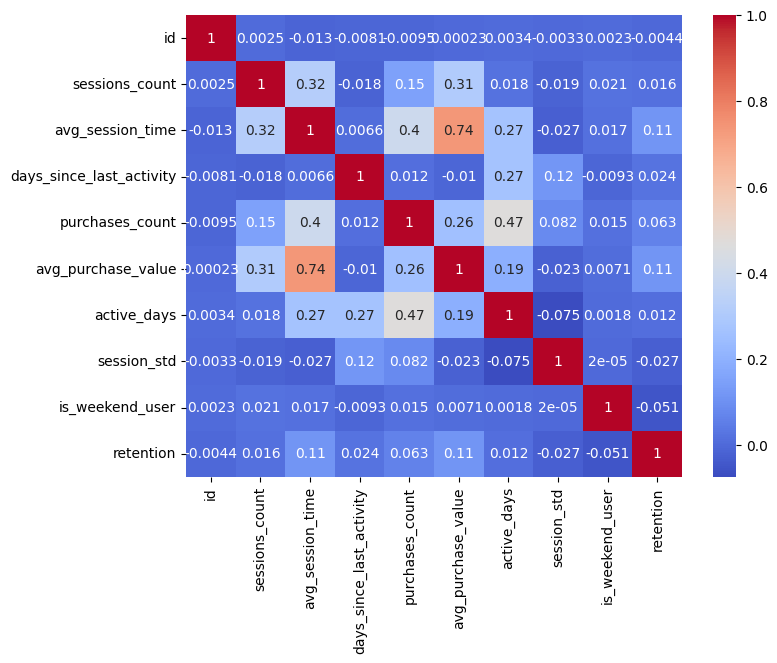

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(train.corr(),annot=True,cmap='coolwarm')
plt.show();

## Visualize Features for better understanding

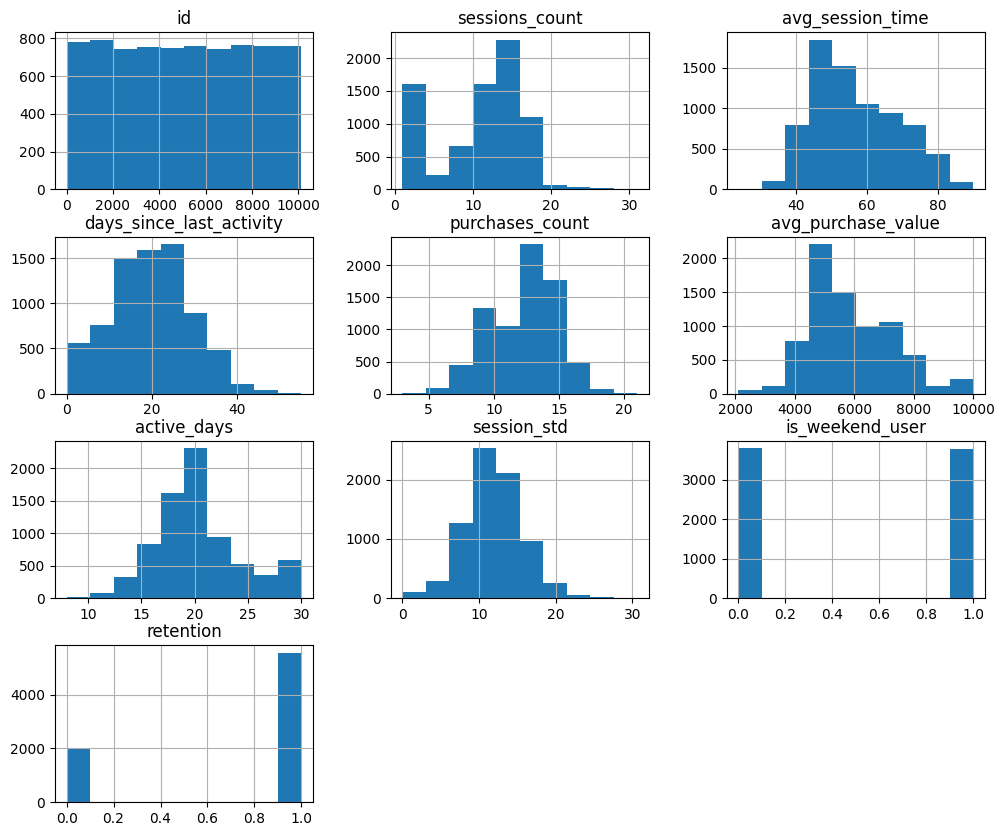

In [112]:
train.hist(figsize=(12,10));

[]

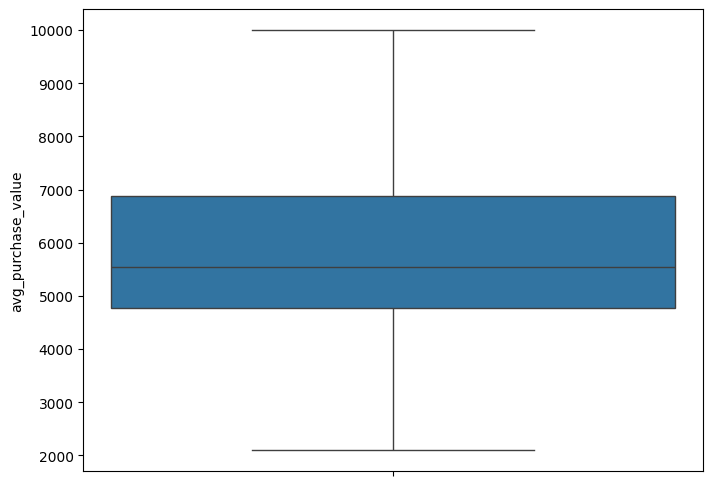

In [113]:
plt.figure(figsize=(8,6))
sns.boxplot(train["avg_purchase_value"])
plt.plot()

C:\Users\Avik Maity\AppData\Local\Temp\ipykernel_3956\4226587414.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='retention',data= train,palette='Set1');


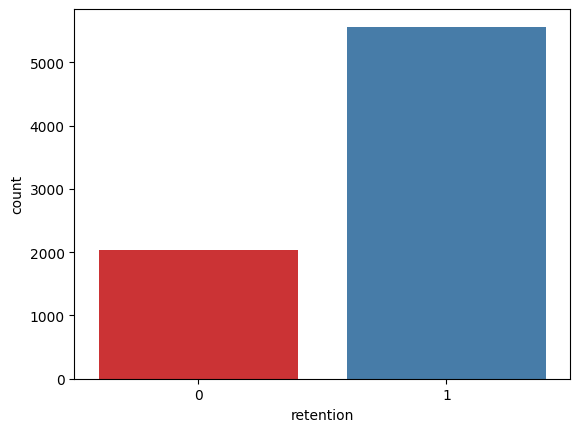

In [114]:
sns.countplot(x='retention',data= train,palette='Set1');

# Step 3. Feature Engineering

In [115]:
# Purchase per session
train['purchases_rate'] = train['purchases_count']/(train['sessions_count']+1)
test['purchases_rate'] = test['purchases_count']/(test['sessions_count']+1)

# Revenue
train["total_purchase"] = train["purchases_count"]*train["avg_purchase_value"]
test["total_purchase"] = test["purchases_count"]*test["avg_purchase_value"]

# Engagement Score
train["engagement"] = (train["sessions_count"] *train["avg_session_time"] *train["active_days"])
test["engagement"] = (test["sessions_count"] *test["avg_session_time"] *test["active_days"])

# Recency
train["recent_score"] = 1/(train["days_since_last_activity"]+1)
test["recent_score"] = 1/(test["days_since_last_activity"]+1)

In [116]:
# check
train.head()

,id,sessions_count,avg_session_time,days_since_last_activity,purchases_count,avg_purchase_value,active_days,session_std,is_weekend_user,retention,purchases_rate,total_purchase,engagement,recent_score
0,1045,16,46.079173,9,13,5462.010418,18,14.307116,1,0,0.764706,71006.135428,13270.801788,0.100000
1,1339,1,42.625268,24,8,4679.746955,14,26.690708,1,1,4.000000,37437.975639,596.753751,0.040000
2,5144,16,67.310472,21,12,6532.157783,21,13.092315,1,1,0.705882,78385.893398,22616.318604,0.045455
3,7099,16,78.904027,34,14,7155.049697,28,10.564979,0,0,0.823529,100170.695758,35349.003966,0.028571
4,7907,8,50.456513,19,12,6214.569079,25,6.813272,1,0,1.333333,74574.828951,10091.302554,0.050000


In [117]:
# Log Transform
import numpy as np

cols=[
"avg_purchase_value",
"avg_session_time",
"engagement",
"total_purchase"
]

for c in cols:
    train[c]=np.log1p(train[c])
    test[c]=np.log1p(test[c])

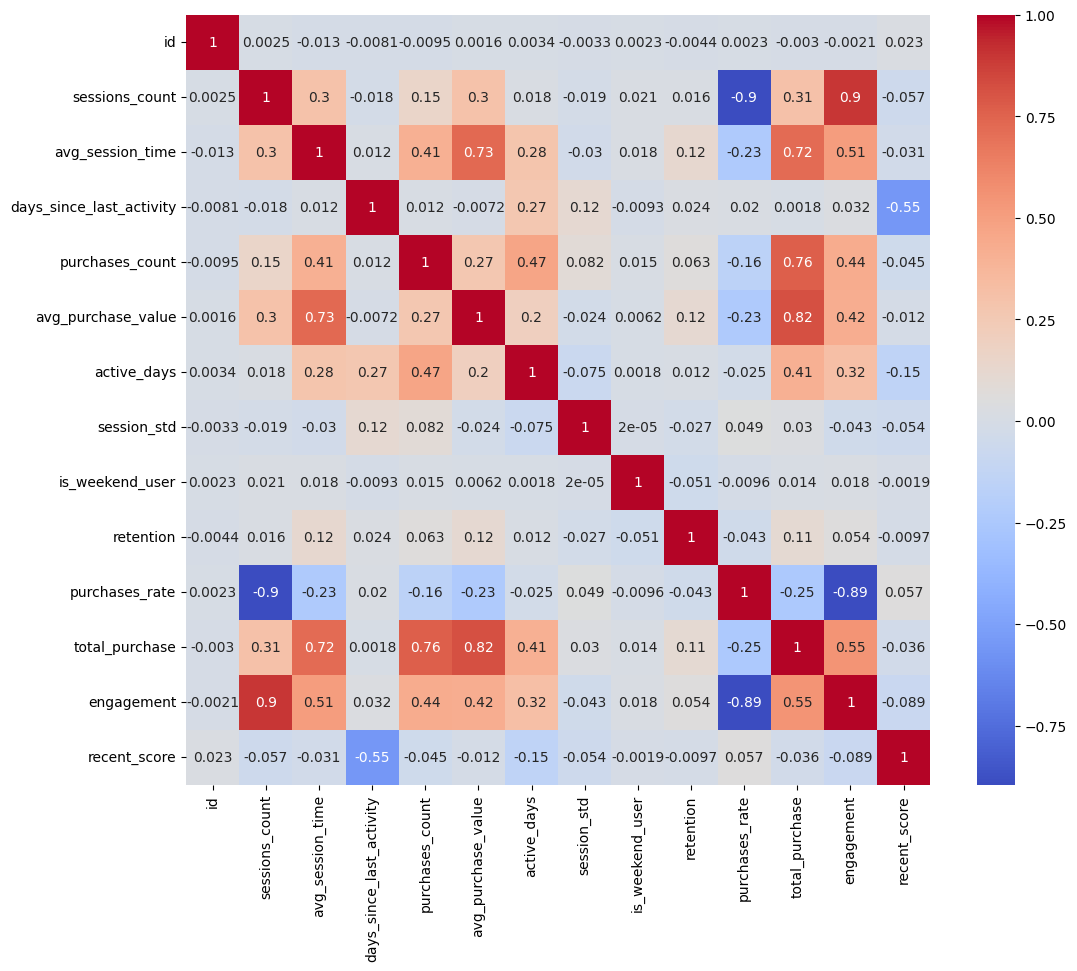

In [118]:
plt.figure(figsize=(12,10))
sns.heatmap(train.corr(),annot=True,cmap='coolwarm')
plt.show();

# Step 4. Train Validation Split

In [119]:
from sklearn.model_selection import train_test_split

X=train.drop(["id","retention"],axis=1)
y=train["retention"]


X_train,X_valid,y_train,y_valid=train_test_split(X,y,
test_size=0.2,
random_state=42,
stratify=y
)

# Step 5. Modeling

### Logistic Regression

In [147]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(class_weight='balanced',max_iter=1000)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [148]:
from sklearn.metrics import roc_auc_score

pred=model.predict_proba(X_valid)[:,1]

roc_auc_score(y_valid,pred)

0.6371701164866632

### Random Forest

In [122]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
n_estimators=500,
random_state=42
)

rf.fit(X_train,y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [134]:
pred_rf=rf.predict_proba(X_valid)[:,1]

roc_auc_score(y_valid,pred_rf)

0.6599382656037333

### XGBoost



In [124]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
n_estimators=500,
learning_rate=0.05,
max_depth=5,
subsample=0.8,
colsample_bytree=0.8,
random_state=42,
eval_metric="logloss"
)

xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [125]:
pred_xgb=xgb.predict_proba(X_valid)[:,1]

roc_auc_score(y_valid,pred_xgb)

0.6574403867569335

### LightGBM

In [131]:
from lightgbm import LGBMClassifier

lgb=LGBMClassifier(
n_estimators=500,
learning_rate=0.05,
random_state=42
)

lgb.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 4449, number of negative: 1627
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1608
[LightGBM] [Info] Number of data points in the train set: 6076, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.732225 -> initscore=1.005942
[LightGBM] [Info] Start training from score 1.005942


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [132]:
pred_lgb=lgb.predict_proba(X_valid)[:,1]

roc_auc_score(y_valid,pred_lgb)

0.6375965566613049

### CatBoost

In [128]:
from catboost import CatBoostClassifier

cat=CatBoostClassifier(
iterations=1000,
learning_rate=0.03,
depth=6,
loss_function="Logloss",
eval_metric="AUC",
verbose=100,
random_seed=42
)

cat.fit(X_train,y_train)

0:	total: 154ms	remaining: 2m 34s
100:	total: 700ms	remaining: 6.23s
200:	total: 1.1s	remaining: 4.38s
300:	total: 1.55s	remaining: 3.6s
400:	total: 2.07s	remaining: 3.09s
500:	total: 2.78s	remaining: 2.77s
600:	total: 3.75s	remaining: 2.49s
700:	total: 4.76s	remaining: 2.03s
800:	total: 5.66s	remaining: 1.41s
900:	total: 6.46s	remaining: 710ms
999:	total: 7.2s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [129]:
pred_cat=cat.predict_proba(X_valid)[:,1]

roc_auc_score(y_valid,pred_cat)

0.66273222208474

# Step 6 . Cross Validation

In [150]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

cv=StratifiedKFold(
n_splits=5,
shuffle=True,
random_state=42
)

scores=cross_val_score(cat,X,y,cv=cv,scoring="roc_auc")

print(scores.mean())

0:	total: 6.64ms	remaining: 6.63s
100:	total: 431ms	remaining: 3.84s
200:	total: 783ms	remaining: 3.11s
300:	total: 1.2s	remaining: 2.78s
400:	total: 1.67s	remaining: 2.5s
500:	total: 2.08s	remaining: 2.07s
600:	total: 2.5s	remaining: 1.66s
700:	total: 2.88s	remaining: 1.23s
800:	total: 3.32s	remaining: 825ms
900:	total: 3.89s	remaining: 427ms
999:	total: 4.47s	remaining: 0us
0:	total: 5.08ms	remaining: 5.07s
100:	total: 701ms	remaining: 6.24s
200:	total: 1.27s	remaining: 5.04s
300:	total: 1.78s	remaining: 4.15s
400:	total: 2.4s	remaining: 3.58s
500:	total: 2.98s	remaining: 2.97s
600:	total: 3.55s	remaining: 2.35s
700:	total: 4.11s	remaining: 1.75s
800:	total: 4.69s	remaining: 1.17s
900:	total: 5.24s	remaining: 576ms
999:	total: 5.79s	remaining: 0us
0:	total: 6.57ms	remaining: 6.56s
100:	total: 624ms	remaining: 5.56s
200:	total: 1.24s	remaining: 4.92s
300:	total: 1.8s	remaining: 4.18s
400:	total: 2.35s	remaining: 3.51s
500:	total: 2.93s	remaining: 2.91s
600:	total: 3.6s	remaining: 2.39

# Step 7. Feature Importance

<Axes: >

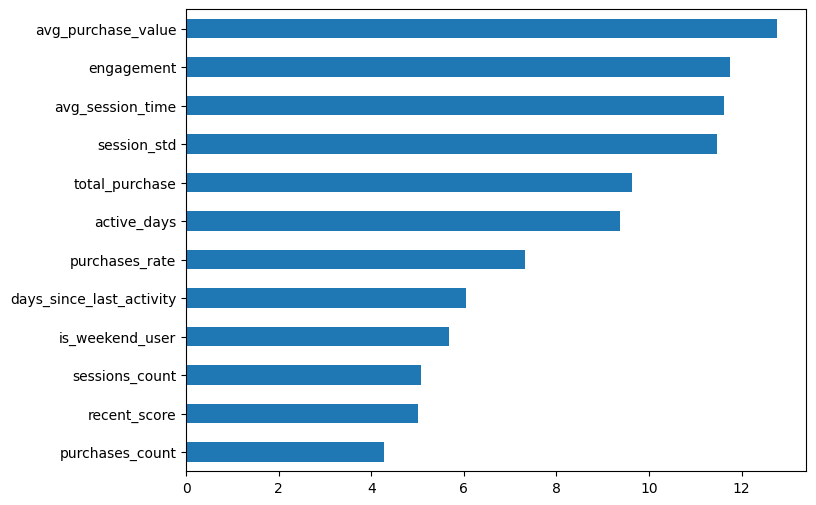

In [137]:
importance=cat.get_feature_importance()

pd.Series(
importance,
index=X.columns
).sort_values().plot.barh(figsize=(8,6))

# Step 8. Train on Full Dataset

In [138]:

cat.fit(X,y)

0:	total: 6.81ms	remaining: 6.8s
100:	total: 460ms	remaining: 4.09s
200:	total: 1.04s	remaining: 4.15s
300:	total: 1.48s	remaining: 3.45s
400:	total: 1.94s	remaining: 2.89s
500:	total: 2.37s	remaining: 2.35s
600:	total: 2.95s	remaining: 1.96s
700:	total: 3.58s	remaining: 1.53s
800:	total: 4.18s	remaining: 1.04s
900:	total: 4.8s	remaining: 528ms
999:	total: 5.44s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=100)

In [139]:
X_test=test.drop("id",axis=1)

pred=cat.predict_proba(X_test)[:,1]